In [206]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pywt
import os
import glob
import itertools
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

# Thuật toán sử dụng Biến đổi Wavelet Rời rạc (DWT) để lấy dải tần số thấp (LL)
def wavelet_hash_pywt(image, size=(64, 64), wavelet='haar'):
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    gray = cv2.resize(gray, size)
    gray = np.float32(gray) / 255.0
    
    coeffs = pywt.wavedec2(gray, wavelet, level=1)
    LL, (LH, HL, HH) = coeffs 
    
    avg = np.mean(LL)
    diff = LL > avg
    return diff.flatten()

def get_hamming_distance(hash1, hash2):
    return np.count_nonzero(hash1 != hash2)

In [207]:
import os

def load_pairs(pairs):
    valid_pairs = []

    for img1, img2, name1, name2 in pairs:
        if img1 is not None and img2 is not None:
            valid_pairs.append((img1, img2, name1, name2))
        else:
            print(f"Lỗi: Không đọc được ảnh {name1} hoặc {name2}")
    return valid_pairs

similar_folder = '../wavelet/dataset/similar'
different_folder = '../wavelet/dataset/different'

raw_similar = []
raw_dissimilar = []

#Quét tự động ảnh Similar
orig_name = "original.jpg"
orig_img = cv2.imread(f"{similar_folder}/{orig_name}")

if orig_img is not None:
    sim_paths = glob.glob(f"{similar_folder}/*.jpg")
    for path in sim_paths:
        if orig_name not in path:
            aug_img = cv2.imread(path)
            aug_name = os.path.basename(path) # Lấy tên file
            # Lưu cả (ảnh 1, ảnh 2, tên 1, tên 2)
            raw_similar.append((orig_img, aug_img, orig_name, aug_name))

# Quét tự động ảnh Dissimilar
diff_paths = glob.glob(f"{different_folder}/*.jpg")
for path1, path2 in itertools.combinations(diff_paths, 2):
    img1 = cv2.imread(path1)
    img2 = cv2.imread(path2)
    name1 = os.path.basename(path1)
    name2 = os.path.basename(path2)
    raw_dissimilar.append((img1, img2, name1, name2))

# Gán biến
similar_pairs = load_pairs(raw_similar)
dissimilar_pairs = load_pairs(raw_dissimilar)
print(f"Đã nạp thành công: {len(similar_pairs)} cặp giống nhau và {len(dissimilar_pairs)} cặp khác nhau.")

Đã nạp thành công: 11 cặp giống nhau và 28 cặp khác nhau.


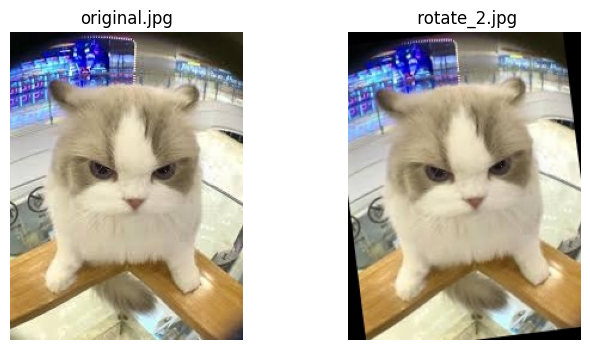

In [208]:

# Lấy cặp ảnh Similar đầu tiên làm ví dụ
img1, img2, name1, name2 = similar_pairs[9] 

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title(f"{name1}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title(f" {name2}")
plt.axis('off')
plt.show()

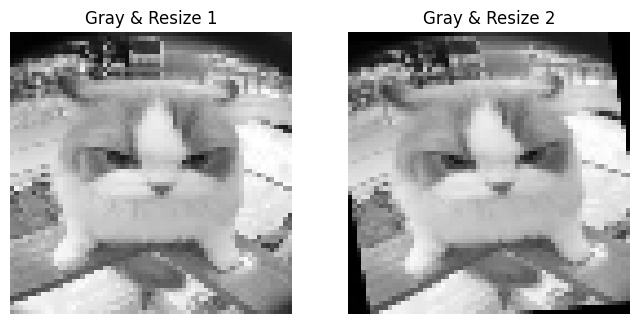

In [209]:
gray1 = cv2.resize(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), (64, 64))
gray2 = cv2.resize(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), (64, 64))

gray1 = np.float32(gray1) / 255.0
gray2 = np.float32(gray2) / 255.0

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(gray1, cmap='gray')
plt.title("Gray & Resize 1")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gray2, cmap='gray')
plt.title("Gray & Resize 2")
plt.axis('off')
plt.show()

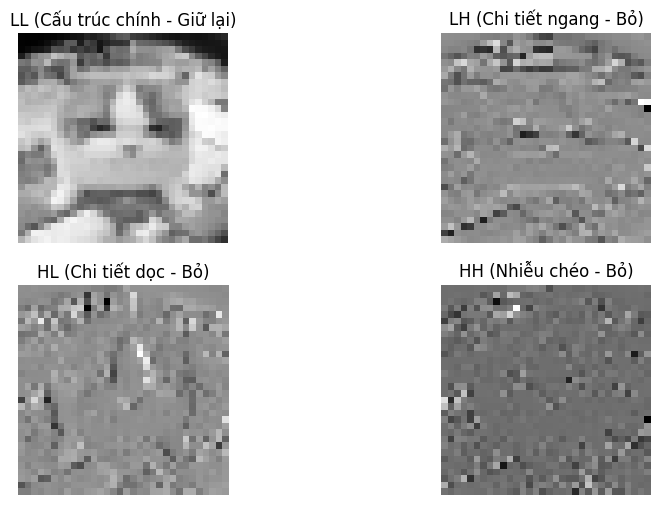

In [210]:
# "Biến đổi Wavelet giúp lọc sạch nhiễu, ta chỉ lấy dải tần số thấp LL – chứa cấu trúc cốt lõi của bức ảnh.
coeffs1 = pywt.wavedec2(gray1, 'haar', level=1)
LL1, (LH1, HL1, HH1) = coeffs1

plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.imshow(LL1, cmap='gray')
plt.title("LL (Cấu trúc chính - Giữ lại)")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(LH1, cmap='gray')
plt.title("LH (Chi tiết ngang - Bỏ)")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(HL1, cmap='gray')
plt.title("HL (Chi tiết dọc - Bỏ)")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(HH1, cmap='gray')
plt.title("HH (Nhiễu chéo - Bỏ)")
plt.axis('off')
plt.show()

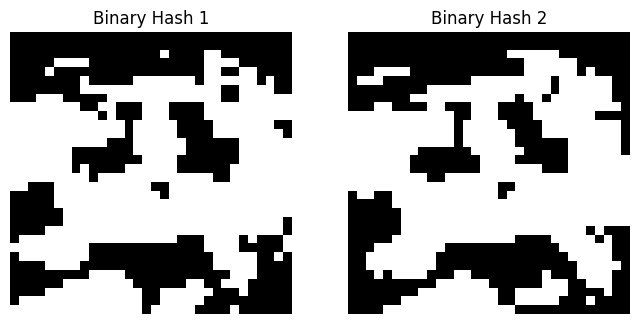

In [211]:
# Mỗi pixel trong vùng LL được so sánh với mức sáng trung bình để tạo thành một đoạn mã vạch đen trắng (0 và 1).
avg1 = np.mean(LL1)
hash1 = LL1 > avg1

coeffs2 = pywt.wavedec2(gray2, 'haar', level=1)
LL2, _ = coeffs2
avg2 = np.mean(LL2)
hash2 = LL2 > avg2

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(hash1, cmap='gray')
plt.title(f"Binary Hash 1")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hash2, cmap='gray')
plt.title(f"Binary Hash 2")
plt.axis('off')
plt.show()

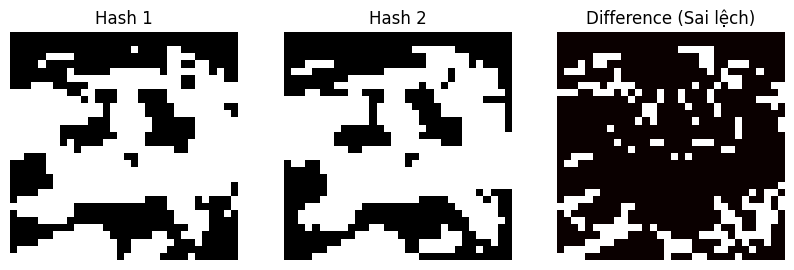

Điểm Hamming (Khoảng cách): 199


In [212]:
# cuối cùng, ta đếm các điểm khác biệt  để ra điểm Hamming. Điểm càng nhỏ thì ảnh càng giống nhau.
diff = hash1 != hash2
distance = np.count_nonzero(diff)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(hash1, cmap='gray')
plt.title("Hash 1")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hash2, cmap='gray')
plt.title("Hash 2")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(diff, cmap='hot')
plt.title(f"Difference (Sai lệch)")
plt.axis('off')
plt.show()

print(f"Điểm Hamming (Khoảng cách): {distance}")

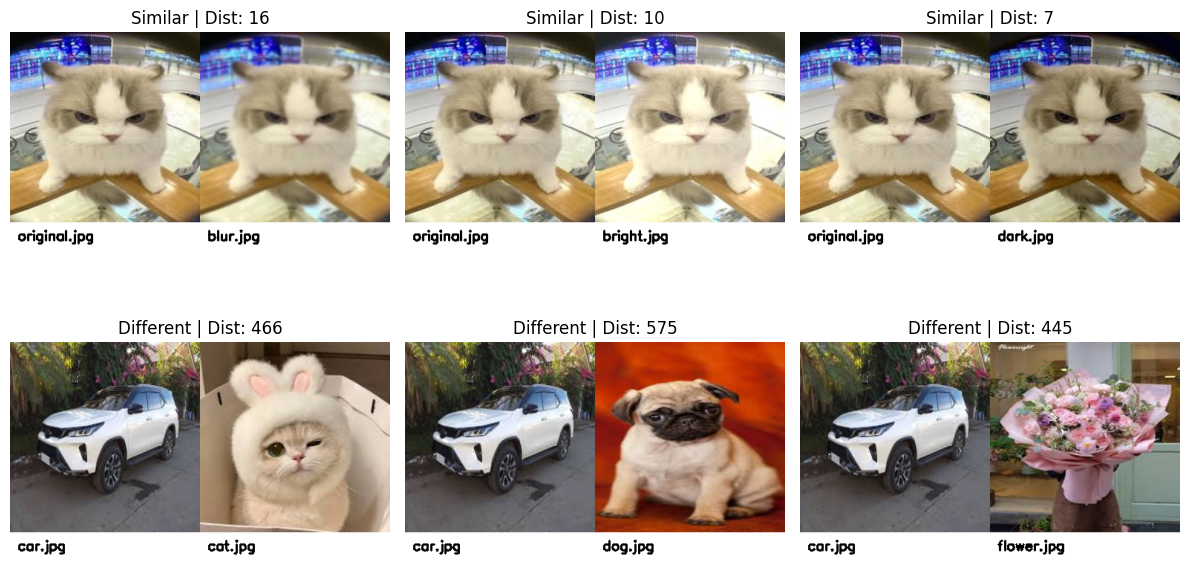

In [213]:
def show_sample_pairs(similar_pairs, dissimilar_pairs, num=3):
    plt.figure(figsize=(12, 7)) # Tăng chiều cao một chút để chứa tên ảnh
    num_sim = min(num, len(similar_pairs))
    num_diff = min(num, len(dissimilar_pairs))

    # Hàm phụ trợ: Thêm viền trắng bên dưới ảnh và ghi tên
    def add_text_below(img, text):
        # 1. Ép kích thước ảnh về 256x256
        img_resized = cv2.resize(img.copy(), (256, 256))
        
        # 2. Tạo một khung canvas nền trắng tinh (cao 296, rộng 256)
        # 40 pixel dư ra ở dưới cùng dùng để viết chữ
        canvas = np.ones((296, 256, 3), dtype=np.uint8) * 255
        
        # 3. Dán bức ảnh vào phần trên của khung trắng
        canvas[0:256, 0:256] = img_resized
        
        # 4. Ghi tên ảnh vào khoảng trắng bên dưới (Chữ màu đen: 0,0,0)
        cv2.putText(canvas, text, (10, 280), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
        return canvas

    for i, (img1, img2, name1, name2) in enumerate(similar_pairs[:num_sim]):
        h1, h2 = wavelet_hash_pywt(img1), wavelet_hash_pywt(img2)
        dist = get_hamming_distance(h1, h2)
        
        # Gọi hàm phụ trợ để xử lý từng ảnh
        disp_img1 = add_text_below(img1, name1)
        disp_img2 = add_text_below(img2, name2)
        
        plt.subplot(2, num, i + 1)
        plt.imshow(cv2.cvtColor(np.hstack((disp_img1, disp_img2)), cv2.COLOR_BGR2RGB))
        plt.title(f"Similar | Dist: {dist}")
        plt.axis('off')

    for i, (img1, img2, name1, name2) in enumerate(dissimilar_pairs[:num_diff]):
        h1, h2 = wavelet_hash_pywt(img1), wavelet_hash_pywt(img2)
        dist = get_hamming_distance(h1, h2)
        
        # Gọi hàm phụ trợ để xử lý từng ảnh
        disp_img1 = add_text_below(img1, name1)
        disp_img2 = add_text_below(img2, name2)
        
        plt.subplot(2, num, i + 1 + num)
        plt.imshow(cv2.cvtColor(np.hstack((disp_img1, disp_img2)), cv2.COLOR_BGR2RGB))
        plt.title(f"Different | Dist: {dist}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Gọi lại hàm
show_sample_pairs(similar_pairs, dissimilar_pairs)

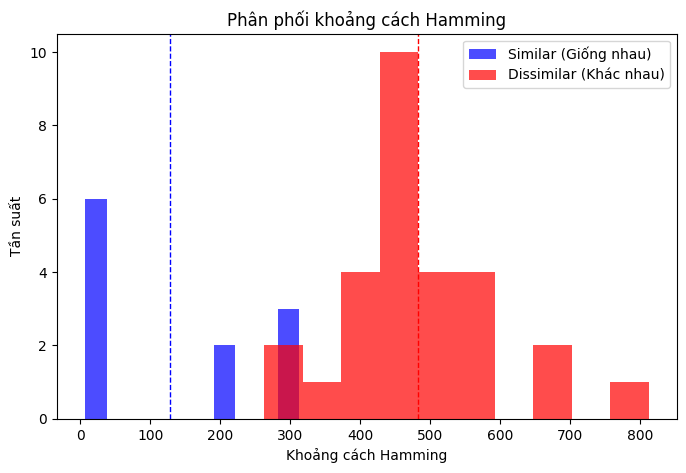

In [ ]:
def plot_distance_histogram(similar_pairs, dissimilar_pairs):
    sim_dist = [get_hamming_distance(wavelet_hash_pywt(img1), wavelet_hash_pywt(img2)) for img1, img2, _, _ in similar_pairs]
    diff_dist = [get_hamming_distance(wavelet_hash_pywt(img1), wavelet_hash_pywt(img2)) for img1, img2, _, _ in dissimilar_pairs]

    plt.figure(figsize=(8, 5))
    plt.hist(sim_dist, bins=10, alpha=0.7, label='Similar (Giống nhau)', color='blue')
    plt.hist(diff_dist, bins=10, alpha=0.7, label='Dissimilar (Khác nhau)', color='red')
    plt.axvline(np.mean(sim_dist), color='blue', linestyle='dashed', linewidth=1)
    plt.axvline(np.mean(diff_dist), color='red', linestyle='dashed', linewidth=1)
    plt.legend()
    plt.title("Phân phối khoảng cách Hamming")
    plt.xlabel("Khoảng cách Hamming")
    plt.ylabel("Tần suất")
    plt.show()

plot_distance_histogram(similar_pairs, dissimilar_pairs)

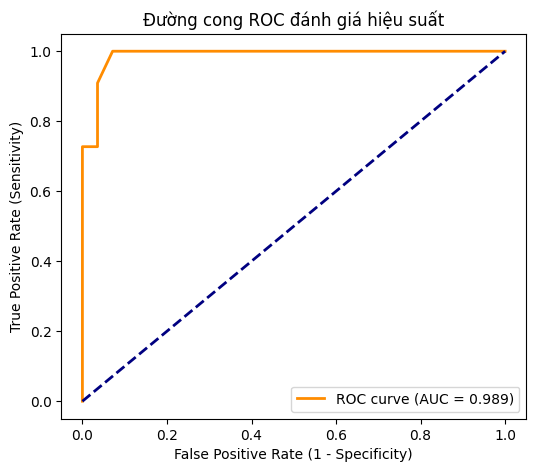

========== KẾT QUẢ ĐÁNH GIÁ TỔNG THỂ ==========
Tổng số cặp ảnh: 39 (11 giống, 28 khác)
Ngưỡng tối ưu (Similarity Score): 0.6943
-----------------------------------------------
1. Độ chính xác (Accuracy)    : 0.9487
2. Độ nhạy (Sensitivity)      : 1.0000
3. Độ đặc hiệu (Specificity)  : 0.9286


In [ ]:
def evaluate_performance(similar_pairs, dissimilar_pairs):
    labels, distances = [], []
    for pairs, label in [(similar_pairs, 1), (dissimilar_pairs, 0)]:
        for img1, img2, name1, name2 in pairs:
            h1, h2 = wavelet_hash_pywt(img1), wavelet_hash_pywt(img2)
            distances.append(get_hamming_distance(h1, h2))
            labels.append(label)

    hash_len = len(wavelet_hash_pywt(np.zeros((64, 64))))
    scores = 1 - (np.array(distances) / hash_len)
    
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Đường cong ROC đánh giá hiệu suất')
    plt.legend(loc="lower right")
    plt.show()

    idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[idx]
    preds = (scores >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    
    print(f"========== KẾT QUẢ ĐÁNH GIÁ TỔNG THỂ ==========")
    print(f"Tổng số cặp ảnh: {len(labels)} ({len(similar_pairs)} giống, {len(dissimilar_pairs)} khác)")
    print(f"Ngưỡng tối ưu (Similarity Score): {best_thresh:.4f}")
    print(f"-----------------------------------------------")
    print(f"1. Độ chính xác (Accuracy)    : {accuracy_score(labels, preds):.4f}")
    print(f"2. Độ nhạy (Sensitivity)      : {tp / (tp + fn):.4f}")
    print(f"3. Độ đặc hiệu (Specificity)  : {tn / (tn + fp):.4f}")

evaluate_performance(similar_pairs, dissimilar_pairs)